# 실습 4: 센서 하나로 이상 구간 찾기
- 상황: 3라인 계측 기록에서 평소와 다르게 튄 구간을 찾아본다
- 목표: 관리선을 긋고 벗어난 구간을 잡는다

## Step 1. 불러오기와 기본 확인

## Step 2. 관리도라는 말부터

### 용어 풀이 - 관리도 주변

| 말 | 뜻 |
|---|---|
| 관리도 | 값을 시간 순서대로 그려두고, 평소 범위를 벗어나는 순간을 잡는 그림 |
| 관리선 | 평소 범위의 경계선. 위쪽 선을 관리 상한, 아래쪽 선을 관리 하한이라 부른다 |
| 평균 | 값들을 다 더해 개수로 나눈 것. 관리도의 한가운데 선이 된다 |
| 표준편차 | 값들이 평균에서 얼마나 흩어져 있는지. 작으면 몰려 있고 크면 넓게 퍼져 있다 |
| 이상 구간 | 관리선을 벗어난 구간. 벗어났다는 것이지 곧 불량이라는 뜻은 아니다 |
| result (판정) | 검사에서 붙은 양품 또는 불량. 공정이 다 끝난 뒤에 붙는다 |
| SPC | 이런 방식으로 공정을 감시하는 것을 통틀어 부르는 말 |

In [6]:
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df = pd.read_csv("../../data/04_secom.csv")

# 1. 전체 행 수와 열 수
print("행 수, 열 수:", df.shape)

# 2. result 열의 값 종류별 건수와 비율
print("\nresult 값별 건수:")
print(df["result"].value_counts())
print("\nresult 값별 비율:")
print(df["result"].value_counts(normalize=True))

# 3. head()로 앞부분 확인
df.head()


행 수, 열 수: (1567, 592)

result 값별 건수:
result
양품    1463
불량     104
Name: count, dtype: int64

result 값별 비율:
result
양품    0.933631
불량    0.066369
Name: proportion, dtype: float64


,measured_at,sensor_001,sensor_002,sensor_003,sensor_004,sensor_005,sensor_006,sensor_007,sensor_008,sensor_009,sensor_010,sensor_011,sensor_012,sensor_013,sensor_014,sensor_015,sensor_016,sensor_017,sensor_018,sensor_019,sensor_020,sensor_021,sensor_022,sensor_023,sensor_024,sensor_025,sensor_026,sensor_027,sensor_028,sensor_029,sensor_030,sensor_031,sensor_032,sensor_033,sensor_034,sensor_035,sensor_036,sensor_037,sensor_038,sensor_039,sensor_040,sensor_041,sensor_042,sensor_043,sensor_044,sensor_045,sensor_046,sensor_047,sensor_048,sensor_049,sensor_050,sensor_051,sensor_052,sensor_053,sensor_054,sensor_055,sensor_056,sensor_057,sensor_058,sensor_059,sensor_060,sensor_061,sensor_062,sensor_063,sensor_064,sensor_065,sensor_066,sensor_067,sensor_068,sensor_069,sensor_070,sensor_071,sensor_072,sensor_073,sensor_074,sensor_075,sensor_076,sensor_077,sensor_078,sensor_079,sensor_080,sensor_081,sensor_082,sensor_083,sensor_084,sensor_085,sensor_086,sensor_087,sensor_088,sensor_089,sensor_090,sensor_091,sensor_092,sensor_093,sensor_094,sensor_095,sensor_096,sensor_097,sensor_098,sensor_099,sensor_100,sensor_101,sensor_102,sensor_103,sensor_104,sensor_105,sensor_106,sensor_107,sensor_108,sensor_109,sensor_110,sensor_111,sensor_112,sensor_113,sensor_114,sensor_115,sensor_116,sensor_117,sensor_118,sensor_119,sensor_120,sensor_121,sensor_122,sensor_123,sensor_124,sensor_125,sensor_126,sensor_127,sensor_128,sensor_129,sensor_130,sensor_131,sensor_132,sensor_133,sensor_134,sensor_135,sensor_136,sensor_137,sensor_138,sensor_139,sensor_140,sensor_141,sensor_142,sensor_143,sensor_144,sensor_145,sensor_146,sensor_147,sensor_148,sensor_149,sensor_150,sensor_151,sensor_152,sensor_153,sensor_154,sensor_155,sensor_156,sensor_157,sensor_158,sensor_159,sensor_160,sensor_161,sensor_162,sensor_163,sensor_164,sensor_165,sensor_166,sensor_167,sensor_168,sensor_169,sensor_170,sensor_171,sensor_172,sensor_173,sensor_174,sensor_175,sensor_176,sensor_177,sensor_178,sensor_179,sensor_180,sensor_181,sensor_182,sensor_183,sensor_184,sensor_185,sensor_186,sensor_187,sensor_188,sensor_189,sensor_190,sensor_191,sensor_192,sensor_193,sensor_194,sensor_195,sensor_196,sensor_197,sensor_198,sensor_199,sensor_200,sensor_201,sensor_202,sensor_203,sensor_204,sensor_205,sensor_206,sensor_207,sensor_208,sensor_209,sensor_210,sensor_211,sensor_212,sensor_213,sensor_214,sensor_215,sensor_216,sensor_217,sensor_218,sensor_219,sensor_220,sensor_221,sensor_222,sensor_223,sensor_224,sensor_225,sensor_226,sensor_227,sensor_228,sensor_229,sensor_230,sensor_231,sensor_232,sensor_233,sensor_234,sensor_235,sensor_236,sensor_237,sensor_238,sensor_239,sensor_240,sensor_241,sensor_242,sensor_243,sensor_244,sensor_245,sensor_246,sensor_247,sensor_248,sensor_249,sensor_250,sensor_251,sensor_252,sensor_253,sensor_254,sensor_255,sensor_256,sensor_257,sensor_258,sensor_259,sensor_260,sensor_261,sensor_262,sensor_263,sensor_264,sensor_265,sensor_266,sensor_267,sensor_268,sensor_269,sensor_270,sensor_271,sensor_272,sensor_273,sensor_274,sensor_275,sensor_276,sensor_277,sensor_278,sensor_279,sensor_280,sensor_281,sensor_282,sensor_283,sensor_284,sensor_285,sensor_286,sensor_287,sensor_288,sensor_289,sensor_290,sensor_291,sensor_292,sensor_293,sensor_294,sensor_295,sensor_296,sensor_297,sensor_298,sensor_299,sensor_300,sensor_301,sensor_302,sensor_303,sensor_304,sensor_305,sensor_306,sensor_307,sensor_308,sensor_309,sensor_310,sensor_311,sensor_312,sensor_313,sensor_314,sensor_315,sensor_316,sensor_317,sensor_318,sensor_319,sensor_320,sensor_321,sensor_322,sensor_323,sensor_324,sensor_325,sensor_326,sensor_327,sensor_328,sensor_329,sensor_330,sensor_331,sensor_332,sensor_333,sensor_334,sensor_335,sensor_336,sensor_337,sensor_338,sensor_339,sensor_340,sensor_341,sensor_342,sensor_343,sensor_344,sensor_345,sensor_346,sensor_347,sensor_348,sensor_349,sensor_350,sensor_351,sensor_352,sensor_353,sensor_354,sensor_355,sensor_356,sensor_357,sensor_358,sensor_359,sensor_360,sensor_361,sensor_362,senso

## Step 3. 센서 하나 고르기

센서 열(sensor_로 시작하는 열) 중에서
빈칸이 없고 값이 실제로 변하는(항상 같은 값이 아닌) 열을 5개만 골라
아래를 한 표로 정리해줘.

1. 센서 이름
2. 값의 범위 (최소 ~ 최대)
3. 서로 다른 값이 몇 가지인지
4. 3번을 보고 판정 — 값 종류가 열 가지 안쪽이면 "정해 넣은 값에 가까움",
   수십 가지 이상이면 "재고 있는 값에 가까움"
   ※ 값 범위가 좁은지 넓은지는 보지 말고, 오직 종류 수로만 판정해줘
5. 2번 자릿수를 보고 어떤 성격일지 한 줄
   (예: 온도처럼 큰 눈금 / 비율 / 아주 미세한 값 / 큰 수로 세는 값)

확실하지 않은 건 확실하지 않다고 적어줘.

채팅에만 쓰지 말고, @lab04_control_chart.ipynb 에 새 코드 칸을 만들어 실행해줘.

In [7]:
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

no_missing = df[sensor_cols].isna().sum() == 0
n_unique_all = df[sensor_cols].nunique()
varies = n_unique_all > 1

candidates = [c for c in sensor_cols if no_missing[c] and varies[c]]
print(f"전체 센서 열: {len(sensor_cols)}개")
print(f"빈칸 없고 값이 변하는 센서 열: {len(candidates)}개")

picked = candidates[:5]
print(f"이번에 고른 5개: {picked}")

rows = []
for c in picked:
    col = df[c]
    vmin, vmax = col.min(), col.max()
    n_unique = col.nunique()

    # 4. 값 종류 수만으로 판정 (범위 폭은 보지 않음)
    if n_unique <= 10:
        judge = "정해 넣은 값에 가까움"
    elif n_unique >= 30:
        judge = "재고 있는 값에 가까움"
    else:
        judge = f"확실하지 않음 (종류 {n_unique}개, 10~30 사이 애매한 구간)"

    # 5. 범위 자릿수로 본 성격 추정 (단위 정보가 없어 전부 추정/확실하지 않음)
    abs_max = max(abs(vmin), abs(vmax))
    if vmin >= 0 and vmax <= 1:
        character = "0~1 사이 비율로 보임 (확실하지 않음)"
    elif abs_max < 0.1:
        character = "아주 미세한 값으로 보임 (확실하지 않음)"
    elif vmin >= 0 and vmax <= 100:
        character = "비율(%)처럼 보임 (확실하지 않음)"
    elif abs_max >= 1000:
        character = "큰 수로 세는 값으로 보임 (확실하지 않음)"
    else:
        character = "온도처럼 중간 크기 눈금으로 보임 (확실하지 않음)"

    rows.append({
        "센서 이름": c,
        "값의 범위 (최소~최대)": f"{vmin} ~ {vmax}",
        "값 종류 수": n_unique,
        "판정 (종류 수 기준)": judge,
        "자릿수로 본 성격 (추정)": character,
    })

result_table = pd.DataFrame(rows)
result_table


전체 센서 열: 590개
빈칸 없고 값이 변하는 센서 열: 52개
이번에 고른 5개: ['sensor_021', 'sensor_087', 'sensor_088', 'sensor_089', 'sensor_114']


,센서 이름,값의 범위 (최소~최대),값 종류 수,판정 (종류 수 기준),자릿수로 본 성격 (추정)
0,sensor_021,1.1797 ~ 1.4534,552,재고 있는 값에 가까움,비율(%)처럼 보임 (확실하지 않음)
1,sensor_087,2.2425 ~ 2.5555,472,재고 있는 값에 가까움,비율(%)처럼 보임 (확실하지 않음)
2,sensor_088,0.7749 ~ 0.9935,249,재고 있는 값에 가까움,0~1 사이 비율로 보임 (확실하지 않음)
3,sensor_089,1627.4714 ~ 2105.1823,973,재고 있는 값에 가까움,큰 수로 세는 값으로 보임 (확실하지 않음)
4,sensor_114,0.8534 ~ 0.9763,468,재고 있는 값에 가까움,0~1 사이 비율로 보임 (확실하지 않음)


[내가 고른 열]<br>
고른 열 : [sensor_089]<br>
값 범위 : [1627.47] ~ [2105.18]   값 종류 : [973]가지<br>
값 종류가 [많으니] 이 열은 [재고 있는 값]에 가깝다<br>
AI가 본 성격 : [세 자리 이상 — 큰 수로 세는 값]

## Step 4. 평소 범위를 정하기
평균에서 표준편차 3배만큼 위아래로 관리선을 긋는다.

In [8]:
# 앞에서 고른 센서 이름을 넣는다 (본인이 고른 것으로 바꾸세요)
센서 = "sensor_089"

# 평균 — 이 센서 값들의 한가운데
평균 = df[센서].mean()

# 표준편차 — 값들이 평균에서 얼마나 흩어져 있는지
표준편차 = df[센서].std()

# 관리 상한 / 하한 — 평균에서 표준편차 3배만큼 위아래
위선 = 평균 + 3 * 표준편차
아래선 = 평균 - 3 * 표준편차

# round(값, 2) — 소수점 둘째 자리까지만 보여준다
print("평균:", round(평균, 2))
print("관리 상한:", round(위선, 2))
print("관리 하한:", round(아래선, 2))


평균: 1807.82
관리 상한: 1968.43
관리 하한: 1647.2


## Step 5. 관리도 그리기

저장 위치: c:\Users\정유진\Desktop\secom-project\day02\lab04_control-chart\results\sensor_089_관리도.png


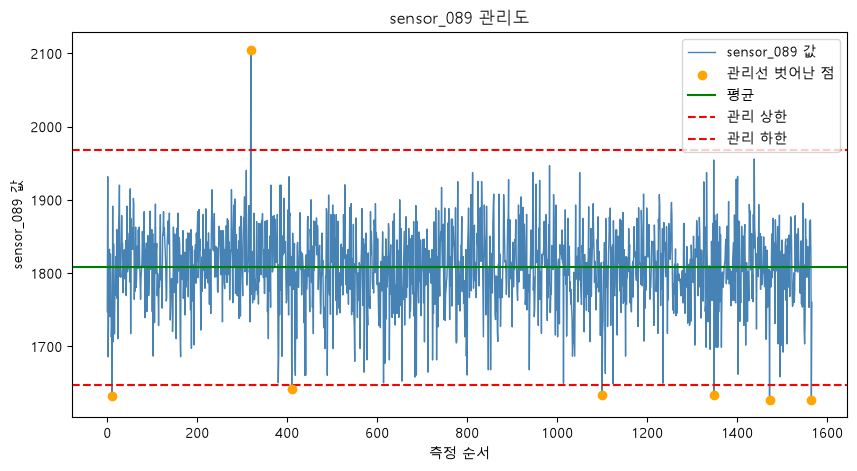

In [9]:
# 그림 그리는 도구, 폴더 만드는 도구를 불러온다
import os
import matplotlib.pyplot as plt

# 한글이 깨지지 않도록 한글 폰트로 지정 (Windows 기본 폰트)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 이 노트북이 있는 폴더 안에 results 폴더를 만든다 (이미 있으면 그냥 둔다)
os.makedirs("results", exist_ok=True)

# 관리선을 벗어난 자리를 True로 표시
이상치 = (df[센서] > 위선) | (df[센서] < 아래선)

plt.figure(figsize=(10, 5))

# 센서 값을 측정 순서대로 선으로 그린다
plt.plot(df[센서], color="steelblue", linewidth=1, label=f"{센서} 값")

# 관리선을 벗어난 점만 다른 색으로 덧그린다
plt.scatter(
    df.index[이상치], df[센서][이상치],
    color="orange", zorder=5, label="관리선 벗어난 점",
)

# axhline — 가로로 쭉 뻗는 선 하나를 긋는다 (h는 horizontal, 수평)
# color는 색, linestyle="--"는 점선, label은 범례(이름표)에 쓸 이름
plt.axhline(평균, color="green", label="평균")
plt.axhline(위선, color="red", linestyle="--", label="관리 상한")
plt.axhline(아래선, color="red", linestyle="--", label="관리 하한")

# 제목과 축 이름
plt.title(f"{센서} 관리도")
plt.xlabel("측정 순서")
plt.ylabel(f"{센서} 값")

# 범례 — 각 선이 무엇인지 알아보는 이름표
plt.legend()

# results 폴더 안에 그림 저장
저장경로 = os.path.join("results", f"{센서}_관리도.png")
plt.savefig(저장경로, dpi=150, bbox_inches="tight")
print("저장 위치:", os.path.abspath(저장경로))

# 그림을 화면에 띄운다
plt.show()


### 문법 노트 - 그림 그리기 첫걸음

| 쓴 것 | 하는 일 |
|---|---|
| plt.plot(값들) | 값을 순서대로 이어 선으로 그린다 |
| plt.axhline(높이) | 그 높이에 가로선 하나를 긋는다. 관리선이 바로 이것 |
| color="red" | 선 색을 정한다 |
| linestyle="--" | 선을 점선으로 만든다 (실선인 평균선과 구분되게) |
| plt.show() | 지금까지 얹은 것들을 한 장으로 띄운다 |
| round(값, 2) | 소수점 둘째 자리까지만 남긴다 |

**한 장의 도화지에 하나씩 얹는 방식이다.**<br>
선을 그리고, 그 위에 가로선을 세 개 얹고, 마지막에 show로 완성해서 보여준다.<br>
그래서 순서대로 쭉 쓰면 된다.

### 저장된 관리도

![sensor_089 관리도](results/sensor_089_관리도.png)


In [10]:
# 관리 상한 또는 하한을 벗어난 행만 고른다
이상행 = df[(df[센서] > 위선) | (df[센서] < 아래선)]
print(f"관리선을 벗어난 행 수: {len(이상행)}개")

# 그 행들의 result 값 건수와 비율
이상행_건수 = 이상행["result"].value_counts()
이상행_비율 = 이상행["result"].value_counts(normalize=True)

# 전체 데이터의 result 비율 (비교용)
전체_비율 = df["result"].value_counts(normalize=True)

비교표 = pd.DataFrame({
    "이상 구간 건수": 이상행_건수,
    "이상 구간 비율": 이상행_비율.round(4),
    "전체 비율": 전체_비율.round(4),
})
비교표


관리선을 벗어난 행 수: 7개


,이상 구간 건수,이상 구간 비율,전체 비율
result,,,
양품,6,0.8571,0.9336
불량,1,0.1429,0.0664


선을 넘은 점 : [7]개<br>
그중 관리 상한을 넘은 점 : [1]개   관리 하한 아래로 내려간 점 : [6]개

## Step 6. 선을 넘은 것이 불량이었나

결과: sensor_089가 관리 상한/하한을 벗어난 행은 총 7개

result	이상 구간 건수	이상 구간 비율	전체 비율
양품	6	85.71%	93.36%
불량	1	14.29%	6.64%
이상 구간에서의 불량 비율(14.29%)이 전체 불량 비율(6.64%)보다 약 2배 이상 높게 나왔습니다. 다만 표본이 7개뿐이라 우연일 가능성도 배제할 수 없다는 점은 감안해야 합니다.

## Step 7. 그런데 590개는요?

센서 1개를 확인하는 데 실행한 코드 칸과 AI 요청 : [5]번<br>
590개를 다 하려면? -> 590 x [5] = [2950]번<br>
게다가 그림 590장을 하나씩 눈으로 봐야 한다.